# Testing of the Entso-E (energy data) and Meteostat (weather) APIs

## Meteostat

In [4]:
from datetime import date

import matplotlib.pyplot as plt
import meteostat as ms
import pandas as pd

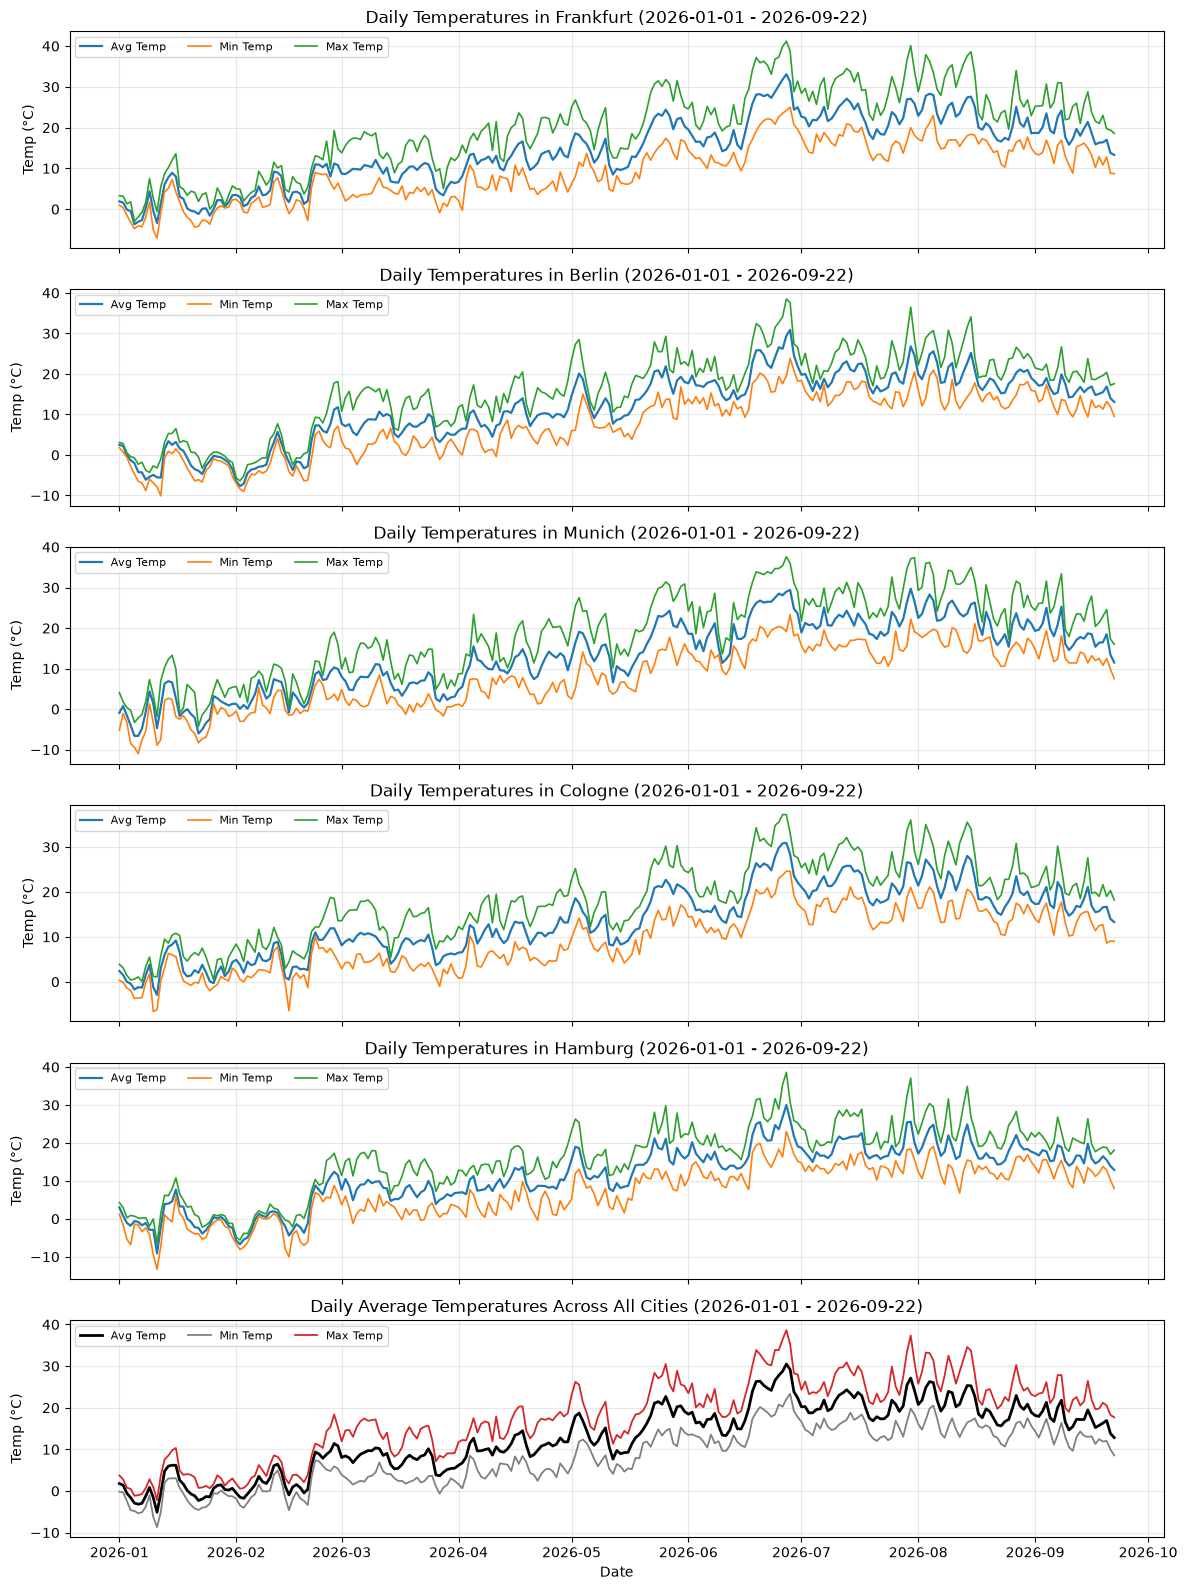

Frankfurt                   Berlin                   Munich  \
                Temp Min Temp Max Temp   Temp Min Temp Max Temp   Temp   
time                                                                     
2026-01-01       1.9      1.0      3.3    2.5      1.8      3.1   -0.9   
2026-01-02       1.6      0.3      3.2    2.2      0.7      2.8    0.8   
2026-01-03      -0.1     -1.5      1.3   -0.0     -0.6      0.5   -1.6   
2026-01-04      -0.5     -3.2      1.8   -1.3     -2.8     -0.4   -4.0   
2026-01-05      -3.7     -4.8     -3.0   -2.0     -4.7     -0.7   -6.6   

                             Cologne                   Hamburg           \
           Min Temp Max Temp    Temp Min Temp Max Temp    Temp Min Temp   
time                                                                      
2026-01-01     -5.2      4.1     2.4      0.3      3.9     3.0      1.2   
2026-01-02     -1.1      1.8     1.5     -0.1      3.1     0.8     -1.6   
2026-01-03     -3.3      0.4     0.0     -1.4      1.4    -1.1     -5.4   
2026-01-04     -8.5     -0.3    -0.4     -1.9      0.4    -1.8     -6.8   
2026-01-05     -9.4     -3.3    -1.7     -3.7      0.6    -0.6     -1.4   

                    Average                    
           Max Temp    Temp Min Temp Max Temp  
time                                           
2026-01-01      4.3    1.78    -0.18     3.74  
2026-01-02      2.9    1.38    -0.36     2.76  
2026-01-03      0.3   -0.56    -2.44     0.78  
2026-01-04      0.9    -1.6    -4.64     0.48  
2026-01-05      0.7   -2.92     -4.8    -1.14

In [5]:
# Specify locations and time range
CITIES = {
    "Frankfurt": ms.Point(50.1155, 8.6842, 113),
    "Berlin": ms.Point(52.5200, 13.4050, 34),
    "Munich": ms.Point(48.1351, 11.5820, 519),
    "Cologne": ms.Point(50.9375, 6.9603, 37),
    "Hamburg": ms.Point(53.5511, 9.9937, 8),
}

START = date(2026, 1, 1)
END = date(2026, 9, 22)

# Fetch daily average, minimum and maximum temperature for each city
city_weather = {}
for city_name, point in CITIES.items():
    stations = ms.stations.nearby(point, limit=4)
    ts = ms.daily(stations, START, END)
    city_df = ms.interpolate(ts, point).fetch()
    city_weather[city_name] = city_df[[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX]].rename(
        columns={
            ms.Parameter.TEMP: "Temp",
            ms.Parameter.TMIN: "Min Temp",
            ms.Parameter.TMAX: "Max Temp",
        }
    )

# Build per-metric dataframes across all cities
temp_df = pd.DataFrame({city: metrics["Temp"] for city, metrics in city_weather.items()})
tmin_df = pd.DataFrame({city: metrics["Min Temp"] for city, metrics in city_weather.items()})
tmax_df = pd.DataFrame({city: metrics["Max Temp"] for city, metrics in city_weather.items()})

# Plot one axis per city + one axis for overall averages
fig, axes = plt.subplots(len(CITIES) + 1, 1, figsize=(12, 16), sharex=True)

for index, city_name in enumerate(CITIES):
    city_metrics = city_weather[city_name]
    axes[index].plot(city_metrics.index, city_metrics["Temp"], label="Avg Temp", linewidth=1.6)
    axes[index].plot(city_metrics.index, city_metrics["Min Temp"], label="Min Temp", linewidth=1.2)
    axes[index].plot(city_metrics.index, city_metrics["Max Temp"], label="Max Temp", linewidth=1.2)
    axes[index].set_title(f"Daily Temperatures in {city_name} ({START} - {END})")
    axes[index].set_ylabel("Temp (°C)")
    axes[index].grid(alpha=0.3)
    axes[index].legend(loc="upper left", ncol=3, fontsize=8)

avg_weather_df = pd.DataFrame(
    {
        "Temp": temp_df.mean(axis=1),
        "Min Temp": tmin_df.mean(axis=1),
        "Max Temp": tmax_df.mean(axis=1),
    }
)

axes[-1].plot(avg_weather_df.index, avg_weather_df["Temp"], color="black", linewidth=2, label="Avg Temp")
axes[-1].plot(avg_weather_df.index, avg_weather_df["Min Temp"], color="gray", linewidth=1.3, label="Min Temp")
axes[-1].plot(avg_weather_df.index, avg_weather_df["Max Temp"], color="tab:red", linewidth=1.3, label="Max Temp")
axes[-1].set_title(f"Daily Average Temperatures Across All Cities ({START} - {END})")
axes[-1].set_xlabel("Date")
axes[-1].set_ylabel("Temp (°C)")
axes[-1].grid(alpha=0.3)
axes[-1].legend(loc="upper left", ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

combined_df = pd.concat(city_weather, axis=1)
combined_df[("Average", "Temp")] = avg_weather_df["Temp"]
combined_df[("Average", "Min Temp")] = avg_weather_df["Min Temp"]
combined_df[("Average", "Max Temp")] = avg_weather_df["Max Temp"]

combined_df.head()

In [6]:
import os

import pandas as pd
from entsoe import EntsoePandasClient

api_key = os.getenv("ENTSOE_API_KEY")
client = EntsoePandasClient(api_key=api_key)

start = pd.Timestamp("20171201", tz="Europe/Brussels")
end = pd.Timestamp("20180101", tz="Europe/Brussels")
country_code = "DE"  # Germany

client.query_load(country_code, start=start, end=end)

,Actual Load
2017-12-01 00:00:00+01:00,55383.26
2017-12-01 00:15:00+01:00,54738.75
2017-12-01 00:30:00+01:00,54487.10
2017-12-01 00:45:00+01:00,54048.15
2017-12-01 01:00:00+01:00,53485.29
...,...
2017-12-31 22:45:00+01:00,46459.48
2017-12-31 23:00:00+01:00,46019.06
2017-12-31 23:15:00+01:00,45465.90
2017-12-31 23:30:00+01:00,44964.79
